# 🧠 Interactive Simulator: Hacking the Human Eye

### Welcome, Visual Psychologists!
When a person looks at your photograph, you have less than a second to capture their attention. If the geometry in your frame is messy, their brain gets confused and they look away. If the geometry uses **Gestalt Principles**, their brain feels satisfied, and they keep looking.

In this notebook, we will use Python to recreate classic psychological tests. We will trick your brain into seeing shapes that do not actually exist, and we will simulate the geometry of Henri Cartier-Bresson's "Decisive Moment."

**Teacher Instructions:** Run the cells below to experience these visual phenomena in real-time.

# 🧠 Interactive Simulator: Visual Perception & The Human Limit

### Photography is Visual Communication
Photography is like talking, but with pictures instead of words! When we take a photo, our goal is usually to share a feeling or an idea with someone else. 

Great photographers know a secret: if you understand how human eyes and brains actually look at pictures, your art becomes much more powerful. When someone looks at your photograph, their reaction comes from three things mixed together: 
1. **Physics:** The actual light hitting their eyes.
2. **Emotion:** How the picture makes them feel inside.
3. **Experience:** The memories the picture brings back to them.

### The Myth of Technical Perfection
Because human eyes and brains are not perfect computers, a photo doesn't always need to be technically "perfect" (like having maximum sharpness or zero grain) to be a masterpiece. Understanding how our brains take shortcuts allows a photographer to stop worrying about making the math perfect, and start focusing on making the art meaningful.

**Teacher Instructions:** Run the code below to see a test of Human Vision vs. Technical Accomplishment.

/home/pjercic/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


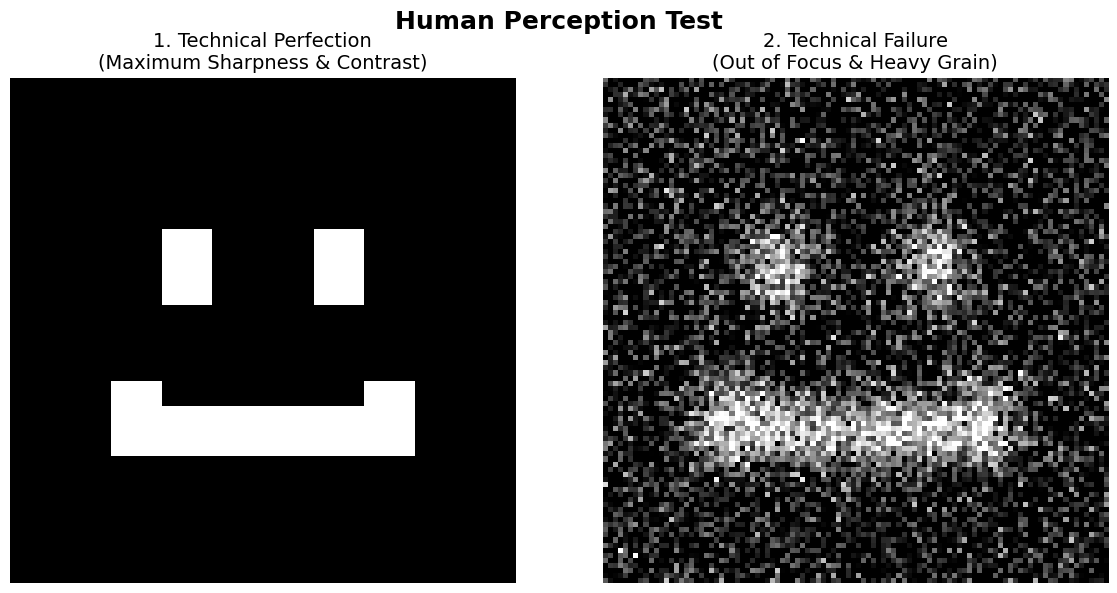

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.ndimage import gaussian_filter

def perception_vs_technical_perfection():
    """
    Demonstrates that human perception (emotion/experience) can easily 
    recognize subjects even when technical limits are severely degraded.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Create a base canvas (100x100 pixels)
    img = np.zeros((100, 100))
    
    # Draw a recognizable, emotional shape (A happy face)
    # Eyes
    img[30:45, 30:40] = 1.0 
    img[30:45, 60:70] = 1.0 
    # Smile (using a simple blocky curve)
    img[65:75, 20:80] = 1.0
    img[60:75, 20:30] = 1.0
    img[60:75, 70:80] = 1.0
    
    # --- IMAGE A: High Technical Accomplishment ---
    # Perfectly sharp, high contrast, zero noise.
    axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title("1. Technical Perfection\n(Maximum Sharpness & Contrast)", fontsize=14)
    axes[0].axis('off')
    
    # --- IMAGE B: Low Technical Accomplishment ---
    # We will ruin the physics of the image! 
    # Add heavy blur (poor focus) and heavy noise (high ISO film grain)
    ruined_img = gaussian_filter(img, sigma=4.0) # Out of focus
    noise = np.random.normal(0, 0.3, ruined_img.shape) # Add heavy grain
    ruined_img = np.clip(ruined_img + noise, 0, 1)
    
    axes[1].imshow(ruined_img, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title("2. Technical Failure\n(Out of Focus & Heavy Grain)", fontsize=14)
    axes[1].axis('off')
    
    plt.suptitle("Human Perception Test", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the perception simulator!
perception_vs_technical_perfection()

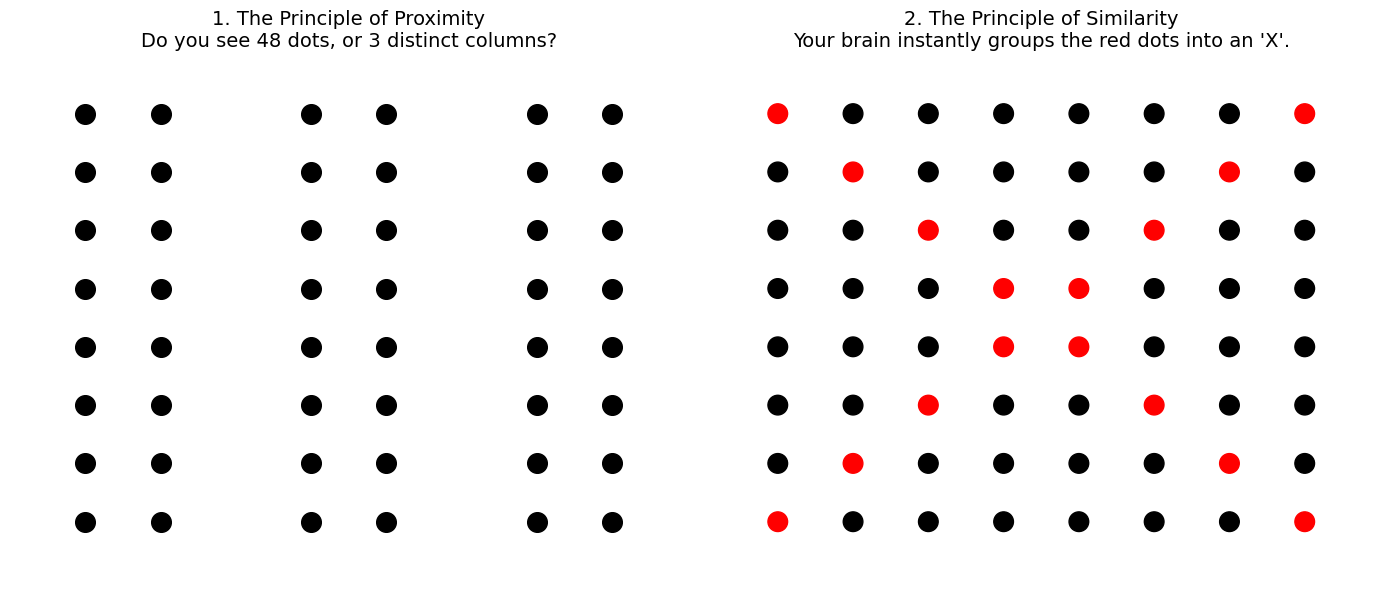

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

def simulate_gestalt_basics():
    """Simulates the Gestalt principles of Proximity and Similarity."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 1. PROXIMITY ---
    # Draw a grid of dots, but space the columns unevenly
    x_prox = []
    y_prox = []
    for x in [1, 2,  4, 5,  7, 8]: # Notice the gaps at x=3 and x=6
        for y in range(1, 9):
            x_prox.append(x)
            y_prox.append(y)
            
    axes[0].scatter(x_prox, y_prox, s=200, color='black')
    axes[0].set_title("1. The Principle of Proximity\nDo you see 48 dots, or 3 distinct columns?", fontsize=14)
    axes[0].axis('off')
    axes[0].set_xlim(0, 9)
    axes[0].set_ylim(0, 9)

    # --- 2. SIMILARITY ---
    # Draw an evenly spaced grid, but change the colors of specific dots
    x_sim = []
    y_sim = []
    colors = []
    for x in range(1, 9):
        for y in range(1, 9):
            x_sim.append(x)
            y_sim.append(y)
            # Make a hidden 'X' shape using color
            if x == y or x + y == 9:
                colors.append('red')
            else:
                colors.append('black')

    axes[1].scatter(x_sim, y_sim, s=200, c=colors)
    axes[1].set_title("2. The Principle of Similarity\nYour brain instantly groups the red dots into an 'X'.", fontsize=14)
    axes[1].axis('off')
    axes[1].set_xlim(0, 9)
    axes[1].set_ylim(0, 9)

    plt.tight_layout()
    plt.show()

# Run the Gestalt simulator!
simulate_gestalt_basics()

### 🔍 Analysis: Proximity and Similarity
In the first image, your brain refuses to see 48 individual dots. Because of the spacing (**Proximity**), it forces you to see three vertical columns. 

In the second image, the spacing is perfectly even. However, your brain groups the red dots together (**Similarity**) to form an 'X'. Photographers use this! If you place a subject in a red jacket in a crowd of people wearing black, the viewer's eye will instantly snap to the red jacket.

---

### The Ultimate Trick: Closure
Now, let's look at the most powerful Gestalt principle: **Closure**. Your brain absolutely hates incomplete information. If it sees a broken pattern, it will literally hallucinate lines to fix it. 

Let's generate the famous **Kanizsa Triangle** illusion.

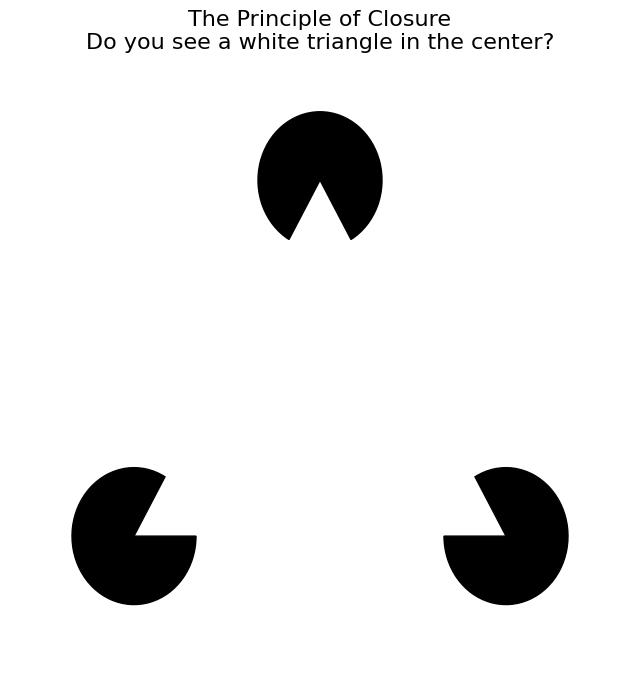

In [2]:
def simulate_closure():
    """Generates the Kanizsa Triangle to demonstrate the principle of Closure."""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Draw three "Pac-Man" shapes (circles with wedges cut out)
    # Bottom Left
    ax.add_patch(patches.Wedge((2, 2), 1, 60, 360, color='black'))
    # Bottom Right
    ax.add_patch(patches.Wedge((8, 2), 1, 180, 120, color='black'))
    # Top Center
    ax.add_patch(patches.Wedge((5, 7.2), 1, -60, 240, color='black'))

    ax.set_title("The Principle of Closure\nDo you see a white triangle in the center?", fontsize=16)
    ax.axis('off')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 9)
    plt.show()

# Run the Closure simulator!
simulate_closure()

### 👤 The Ultimate Shape: Pareidolia and the Face
We just saw how our brains hate incomplete information and will hallucinate a triangle to make sense of the world. But there is one specific shape our brains are looking for more than anything else: **The Human Face.**

A massive portion of human brainpower is dedicated entirely to recognizing faces. In fact, our biological programming works *so* well that logic often takes second place! We constantly spot faces hiding in random places—bathroom tiles, wood grain, or the craters of the "Man in the Moon." This psychological phenomenon of seeing meaningful patterns (like faces) in random data is called **Pareidolia**.



### The Emotional Shortcut
Great photographers know that the human brain cannot ignore a face. They use this biological obsession as an artistic tool. 

Consider Dorothea Lange's famous photograph, *Migrant Mother*. The picture doesn't show you the farm the woman worked on, the date it was taken, or the complex economic history of the Great Depression. It doesn't have to. By capturing the intense worry, exhaustion, and resilience written on just *one* face, Lange bypassed logic and went straight to empathy, summarizing the fate of an entire generation in a single expression.

/home/pjercic/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


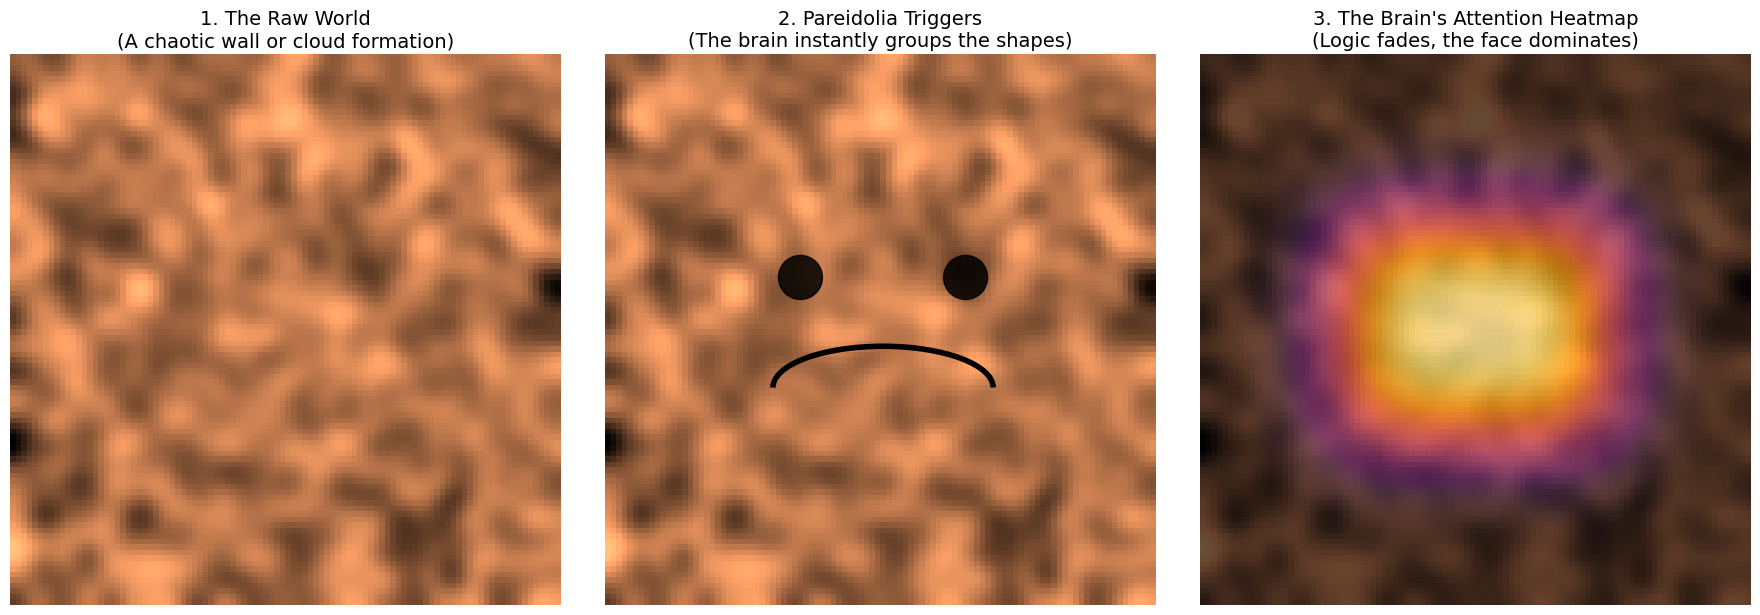

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.ndimage import gaussian_filter

def simulate_facial_attention():
    """
    Simulates Pareidolia and visual attention. 
    Demonstrates how the brain ignores background chaos the moment a face is detected.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Generate a complex, meaningless background texture
    np.random.seed(42)
    chaos = np.random.rand(100, 100)
    chaos = gaussian_filter(chaos, sigma=2.5)
    
    axes[0].imshow(chaos, cmap='copper')
    axes[0].set_title("1. The Raw World\n(A chaotic wall or cloud formation)", fontsize=14)
    axes[0].axis('off')
    
    # 2. Pareidolia: Adding three simple geometric shapes
    axes[1].imshow(chaos, cmap='copper')
    # Add two dots and a curve
    axes[1].add_patch(patches.Circle((35, 40), 4, color='black', alpha=0.85)) # Left eye
    axes[1].add_patch(patches.Circle((65, 40), 4, color='black', alpha=0.85)) # Right eye
    axes[1].add_patch(patches.Arc((50, 60), 40, 15, theta1=0, theta2=180, angle=180, color='black', linewidth=4)) 
    axes[1].set_title("2. Pareidolia Triggers\n(The brain instantly groups the shapes)", fontsize=14)
    axes[1].axis('off')
    
    # 3. The Visual Heatmap
    axes[2].imshow(chaos, cmap='copper')
    # Create an attention heat map focused entirely on the "face"
    heatmap = np.zeros((100, 100))
    heatmap[30:70, 25:75] = 1.0 # Maximum visual weight on the facial features
    heatmap = gaussian_filter(heatmap, sigma=8)
    
    axes[2].imshow(heatmap, cmap='inferno', alpha=0.6)
    axes[2].set_title("3. The Brain's Attention Heatmap\n(Logic fades, the face dominates)", fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the Facial Recognition Simulator!
simulate_facial_attention()

### 🔍 Analysis: Hacking the Heatmap
Look at the third frame. When you look at a photograph containing a person, your brain generates a "heatmap" of attention. You will almost always look at the face *first*, before you look at the background, the clothing, or the lighting. 

By understanding this, you can use faces as anchors in your composition to immediately grab the viewer's attention and dictate exactly how they feel about the image.

### 👻 The Hallucination
There is no white triangle in the code above. The computer only drew three black "Pac-Man" shapes. But your brain connects the invisible dots to create a bright, solid white triangle in the center. 

Photographers use Closure by framing subjects through doorways, windows, or partially behind walls. It forces the viewer's brain to actively participate in building the image!

---

### ⏱️ The Decisive Moment
Cartier-Bresson taught us that a photograph is only successful when the moving action aligns perfectly with the static background geometry. Let's simulate a photographer waiting for someone to walk past a geometric staircase.

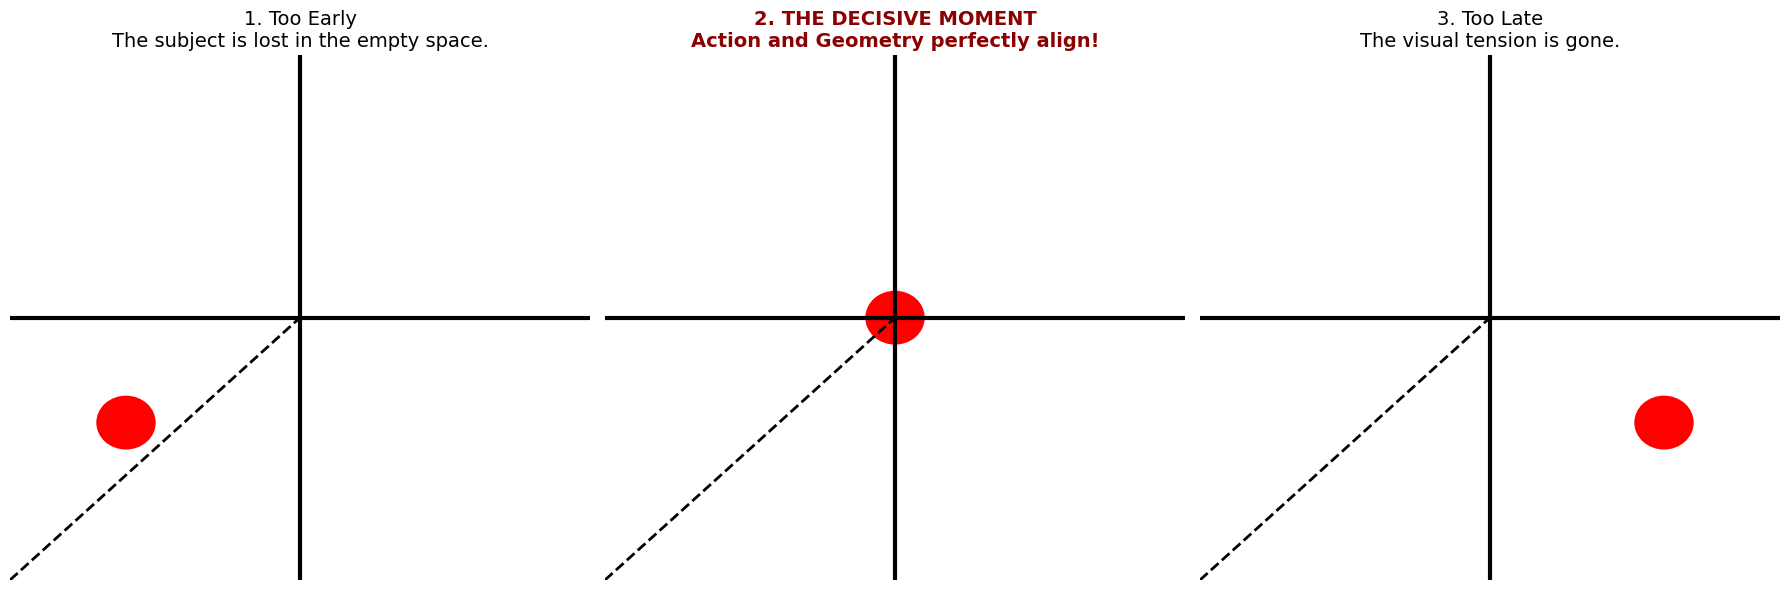

In [3]:
def simulate_decisive_moment():
    """Simulates a subject moving through a geometric background."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # The Background Geometry (Static)
    def draw_background(ax):
        ax.plot([0, 10], [5, 5], 'k-', lw=3) # Horizon line
        ax.plot([5, 5], [0, 10], 'k-', lw=3) # Vertical wall edge
        ax.plot([0, 5], [0, 5], 'k--', lw=2) # Diagonal shadow leading line
        ax.axis('off')
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)

    # Frame 1: Too Early
    draw_background(axes[0])
    axes[0].add_patch(patches.Circle((2, 3), 0.5, color='red')) # Person is on the left
    axes[0].set_title("1. Too Early\nThe subject is lost in the empty space.", fontsize=14)

    # Frame 2: The Decisive Moment
    draw_background(axes[1])
    axes[1].add_patch(patches.Circle((5, 5), 0.5, color='red')) # Person hits the intersection!
    axes[1].set_title("2. THE DECISIVE MOMENT\nAction and Geometry perfectly align!", fontsize=14, fontweight='bold', color='darkred')

    # Frame 3: Too Late
    draw_background(axes[2])
    axes[2].add_patch(patches.Circle((8, 3), 0.5, color='red')) # Person moved past
    axes[2].set_title("3. Too Late\nThe visual tension is gone.", fontsize=14)

    plt.tight_layout()
    plt.show()

# Run the Decisive Moment simulator!
simulate_decisive_moment()

### 📸 The Final Takeaway
Look at the middle frame. When the red dot hits the exact intersection of the vertical line, the horizontal line, and the diagonal shadow, the image feels complete. 

Your camera's shutter speed controls time, but **you** control the timing. Understanding human psychology is what separates a snapshot from a masterpiece.